In [1]:
from nba_api.stats.endpoints import playercareerstats
import pandas as pd

In [2]:
# Kawhi Leonard
career = playercareerstats.PlayerCareerStats(player_id='202695') 
career.get_data_frames()[0]

,PLAYER_ID,SEASON_ID,LEAGUE_ID,TEAM_ID,TEAM_ABBREVIATION,PLAYER_AGE,GP,GS,MIN,FGM,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
0,202695,2011-12,00,1610612759,SAS,21.0,64,39,1534,199,...,0.773,104,223,327,70,85,24,44,88,507
1,202695,2012-13,00,1610612759,SAS,22.0,58,57,1810,260,...,0.825,63,283,346,93,97,32,62,99,689
2,202695,2013-14,00,1610612759,SAS,23.0,66,65,1923,337,...,0.802,76,336,412,133,114,50,80,127,844
3,202695,2014-15,00,1610612759,SAS,24.0,64,64,2033,394,...,0.802,85,376,461,161,148,48,97,128,1057
4,202695,2015-16,00,1610612759,SAS,25.0,72,72,2380,551,...,0.874,95,398,493,186,128,71,105,133,1523
5,202695,2016-17,00,1610612759,SAS,26.0,74,74,2475,636,...,0.880,80,350,430,260,133,55,154,122,1888
6,202695,2017-18,00,1610612759,SAS,27.0,9,9,210,52,...,0.816,6,36,42,21,18,9,16,9,146
7,202695,2018-19,00,1610612761,TOR,28.0,60,60,2040,560,...,0.854,78,361,439,199,106,24,121,87,1596
8,202695,2019-20,00,1610612746,LAC,29.0,57,57,1848,532,...,0.886,54,348,402,280,103,33,149,113,1543
9,202695,2020-21,00,1610612746,LAC,30.0,52,52,1772,465,...,0.885,55,282,337,269,81,21,105,82,1292


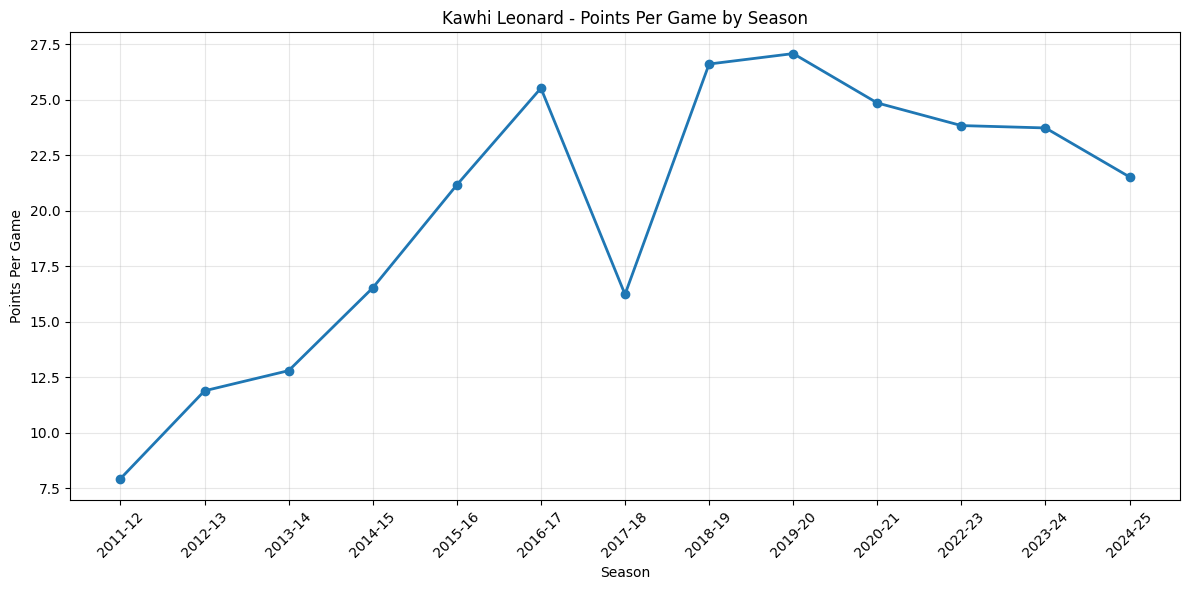

In [3]:
import matplotlib.pyplot as plt

# Get the career stats dataframe
df = career.get_data_frames()[0]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['SEASON_ID'], df['PTS'] / df['GP'], marker='o', linewidth=2, markersize=6)
plt.title("Kawhi Leonard - Points Per Game by Season")
plt.xlabel("Season")
plt.ylabel("Points Per Game")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Create a row for the missing 2021-22 season where Kawhi didn't play
missing_row = {
    'PLAYER_ID': 202695,
    'SEASON_ID': '2021-22',
    'LEAGUE_ID': '00',
    'TEAM_ID': 1610612746,  # LAC team ID
    'TEAM_ABBREVIATION': 'LAC',
    'PLAYER_AGE': 31.0,
    'GP': 0,
    'GS': 0,
    'MIN': 0,
    'FGM': 0,
    'FGA': 0,
    'FG_PCT': 0.0,
    'FG3M': 0,
    'FG3A': 0,
    'FG3_PCT': 0.0,
    'FTM': 0,
    'FTA': 0,
    'FT_PCT': 0.0,
    'OREB': 0,
    'DREB': 0,
    'REB': 0,
    'AST': 0,
    'STL': 0,
    'BLK': 0,
    'TOV': 0,
    'PF': 0,
    'PTS': 0,
    'TS_PCT': 0.0
}

# Add the missing row to the dataframe
df = pd.concat([df, pd.DataFrame([missing_row])], ignore_index=True)
df = df.sort_values('SEASON_ID').reset_index(drop=True)
print(f"Added 2021-22 season. DataFrame now has {len(df)} rows.")

Added 2021-22 season. DataFrame now has 14 rows.


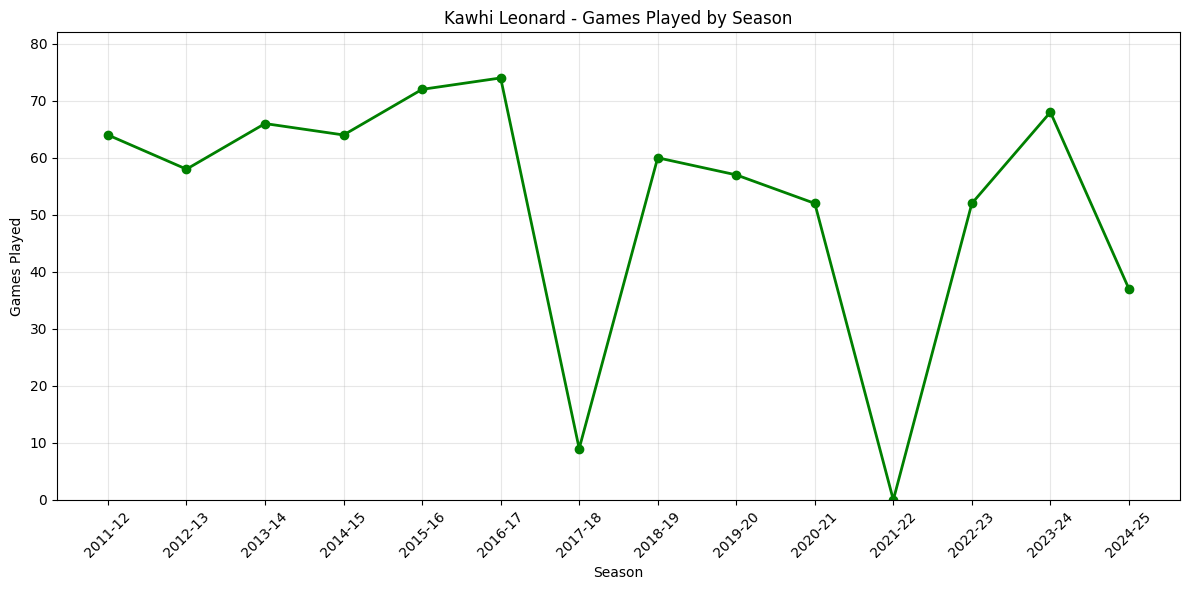

In [5]:
# Note: Not every season had 82 games due to the pandemic and lockouts
plt.figure(figsize=(12, 6))
plt.plot(df['SEASON_ID'], df['GP'], marker='o', linewidth=2, markersize=6, color='green')
plt.title("Kawhi Leonard - Games Played by Season")
plt.xlabel("Season")
plt.ylabel("Games Played")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0, 82)
plt.show()

In [6]:
# Calculate True Shooting Percentage (TS%) for each season
# TS% = PTS / (2 * (FGA + 0.44 * FTA))
df['TS_PCT'] = df['PTS'] / (2 * (df['FGA'] + 0.44 * df['FTA']))

# Use df instead of career since df is the dataframe we're working with
career = df.copy()
# Ensure TS_PCT is numeric, it might be loaded as an object if there are missing values represented by strings.
if 'TS_PCT' in career.columns and 'SEASON_ID' in career.columns:
    career['TS_PCT'] = pd.to_numeric(career['TS_PCT'], errors='coerce')
    
    # Sort by season to ensure the plot is chronological
    career = career.sort_values(by='SEASON_ID')
    
    # Filter out seasons where TS% might be NaN (e.g., if a player didn't have qualifying attempts or data is missing)
    plot_data = career.dropna(subset=['TS_PCT'])
    
    seasons = plot_data['SEASON_ID']
    ts_percentage = plot_data['TS_PCT']
    
    print("\nSeason vs. TS%")
    for season, ts in zip(seasons, ts_percentage):
        print(f"{season}: {ts:.3f}")
else:
    print("Could not find 'SEASON_ID' or 'TS_PCT' in the DataFrame.")
    print("Inspect the DataFrame structure from the previous step.")
    if 'career' in locals():
        print(career.head())
    exit()



Season vs. TS%
2011-12: 0.573
2012-13: 0.592
2013-14: 0.602
2014-15: 0.567
2015-16: 0.616
2016-17: 0.610
2017-18: 0.572
2018-19: 0.606
2019-20: 0.589
2020-21: 0.622
2022-23: 0.623
2023-24: 0.626
2024-25: 0.589


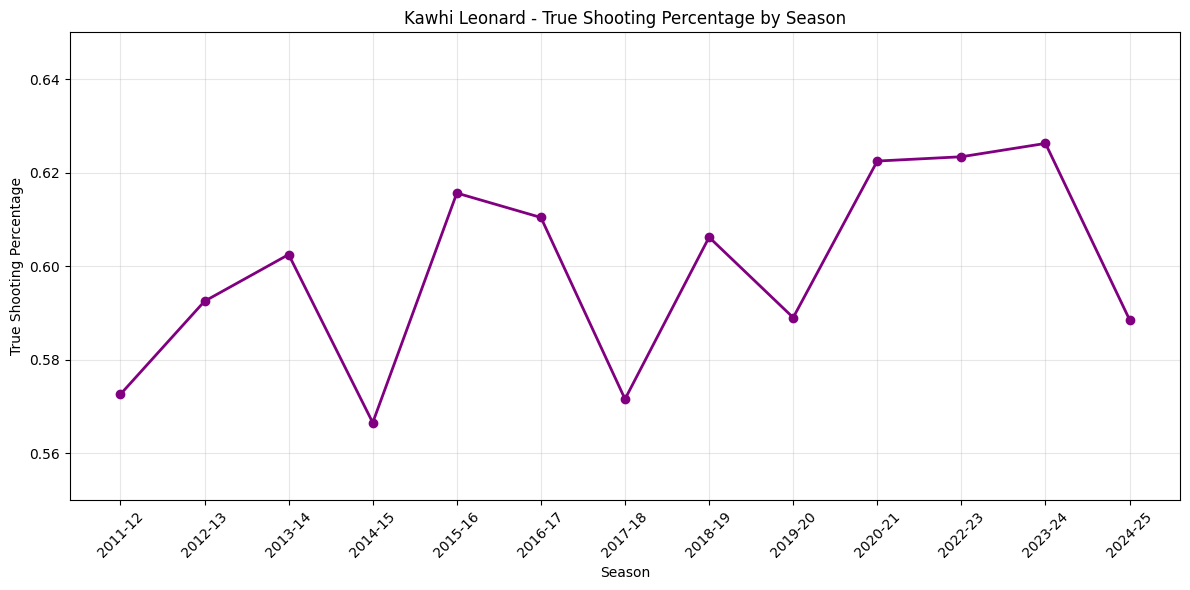

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(plot_data['SEASON_ID'], plot_data['TS_PCT'], marker='o', linewidth=2, markersize=6, color='purple')
plt.title("Kawhi Leonard - True Shooting Percentage by Season")
plt.xlabel("Season")
plt.ylabel("True Shooting Percentage")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.ylim(0.55, 0.65)
plt.tight_layout()
plt.show()

In [8]:
pd.set_option('display.max_columns', None)
df

,PLAYER_ID,SEASON_ID,LEAGUE_ID,TEAM_ID,TEAM_ABBREVIATION,PLAYER_AGE,GP,GS,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,TS_PCT
0,202695,2011-12,00,1610612759,SAS,21.0,64,39,1534,199,404,0.493,41,109,0.376,68,88,0.773,104,223,327,70,85,24,44,88,507,0.572597
1,202695,2012-13,00,1610612759,SAS,22.0,58,57,1810,260,526,0.494,65,174,0.374,104,126,0.825,63,283,346,93,97,32,62,99,689,0.592494
2,202695,2013-14,00,1610612759,SAS,23.0,66,65,1923,337,645,0.522,69,182,0.379,101,126,0.802,76,336,412,133,114,50,80,127,844,0.602478
3,202695,2014-15,00,1610612759,SAS,24.0,64,64,2033,394,822,0.479,67,192,0.349,202,252,0.802,85,376,461,161,148,48,97,128,1057,0.566525
4,202695,2015-16,00,1610612759,SAS,25.0,72,72,2380,551,1090,0.506,129,291,0.443,292,334,0.874,95,398,493,186,128,71,105,133,1523,0.615622
5,202695,2016-17,00,1610612759,SAS,26.0,74,74,2475,636,1312,0.485,147,387,0.380,469,533,0.880,80,350,430,260,133,55,154,122,1888,0.610403
6,202695,2017-18,00,1610612759,SAS,27.0,9,9,210,52,111,0.468,11,35,0.314,31,38,0.816,6,36,42,21,18,9,16,9,146,0.571563
7,202695,2018-19,00,1610612761,TOR,28.0,60,60,2040,560,1129,0.496,112,302,0.371,364,426,0.854,78,361,439,199,106,24,121,87,1596,0.606180
8,202695,2019-20,00,1610612746,LAC,29.0,57,57,1848,532,1133,0.470,123,325,0.378,356,402,0.886,54,348,402,280,103,33,149,113,1543,0.588985
9,202695,2020-21,00,1610612746,LAC,30.0,52,52,1772,465,908,0.512,101,254,0.398,261,295,0.885,55,282,337,269,81,21,105,82,1292,0.622471


Retrieved 64 games for 2011-12
Retrieved 58 games for 2012-13
Retrieved 66 games for 2013-14
Retrieved 64 games for 2014-15
Retrieved 72 games for 2015-16
Retrieved 74 games for 2016-17
Retrieved 9 games for 2017-18
Retrieved 60 games for 2018-19
Retrieved 57 games for 2019-20
Retrieved 52 games for 2020-21
Retrieved 52 games for 2022-23
Retrieved 68 games for 2023-24
Retrieved 37 games for 2024-25


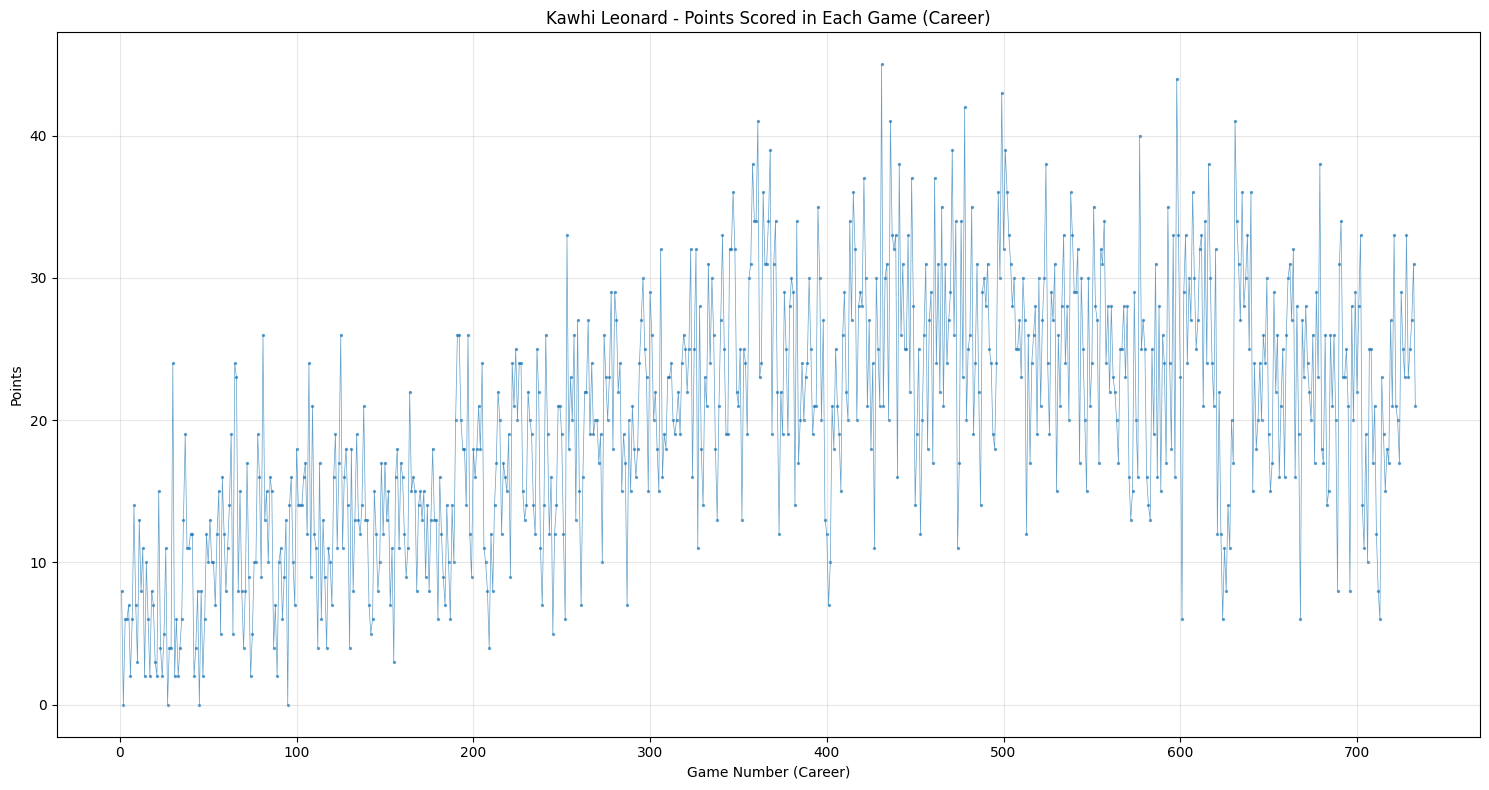

Total games plotted: 733


In [ ]:
from nba_api.stats.endpoints import playergamelog

# Get all seasons from the career data
seasons = df['SEASON_ID'].unique()

# Initialize lists to store game data
all_games_data = []

# Loop through each season to get game logs
for season in seasons:
    if season != '2021-22':  # Skip the manually added season with 0 games
        try:
            # Get game log for the season
            game_log = playergamelog.PlayerGameLog(player_id='202695', season=season)
            season_games = game_log.get_data_frames()[0]
            
            # Add season info to each game
            season_games['SEASON'] = season
            all_games_data.append(season_games)
            print(f"Retrieved {len(season_games)} games for {season}")
        except Exception as e:
            print(f"Error retrieving data for {season}: {e}")

# Combine all game data
if all_games_data:
    all_games_df = pd.concat(all_games_data, ignore_index=True)
    
    # Create a cumulative game number for x-axis
    all_games_df = all_games_df.sort_values(['SEASON_ID', 'GAME_DATE'])
    all_games_df['GAME_NUMBER'] = range(1, len(all_games_df) + 1)
    
    # Plot points per game across entire career
    plt.figure(figsize=(15, 8))
    plt.plot(all_games_df['GAME_NUMBER'], all_games_df['PTS'], alpha=0.7, linewidth=0.5)
    plt.scatter(all_games_df['GAME_NUMBER'], all_games_df['PTS'], alpha=0.6, s=2)
    plt.title("Kawhi Leonard - Points Scored in Each Game (Career)")
    plt.xlabel("Game Number (Career)")
    plt.ylabel("Points")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Total games plotted: {len(all_games_df)}")
else:
    print("No game data retrieved")
    
    

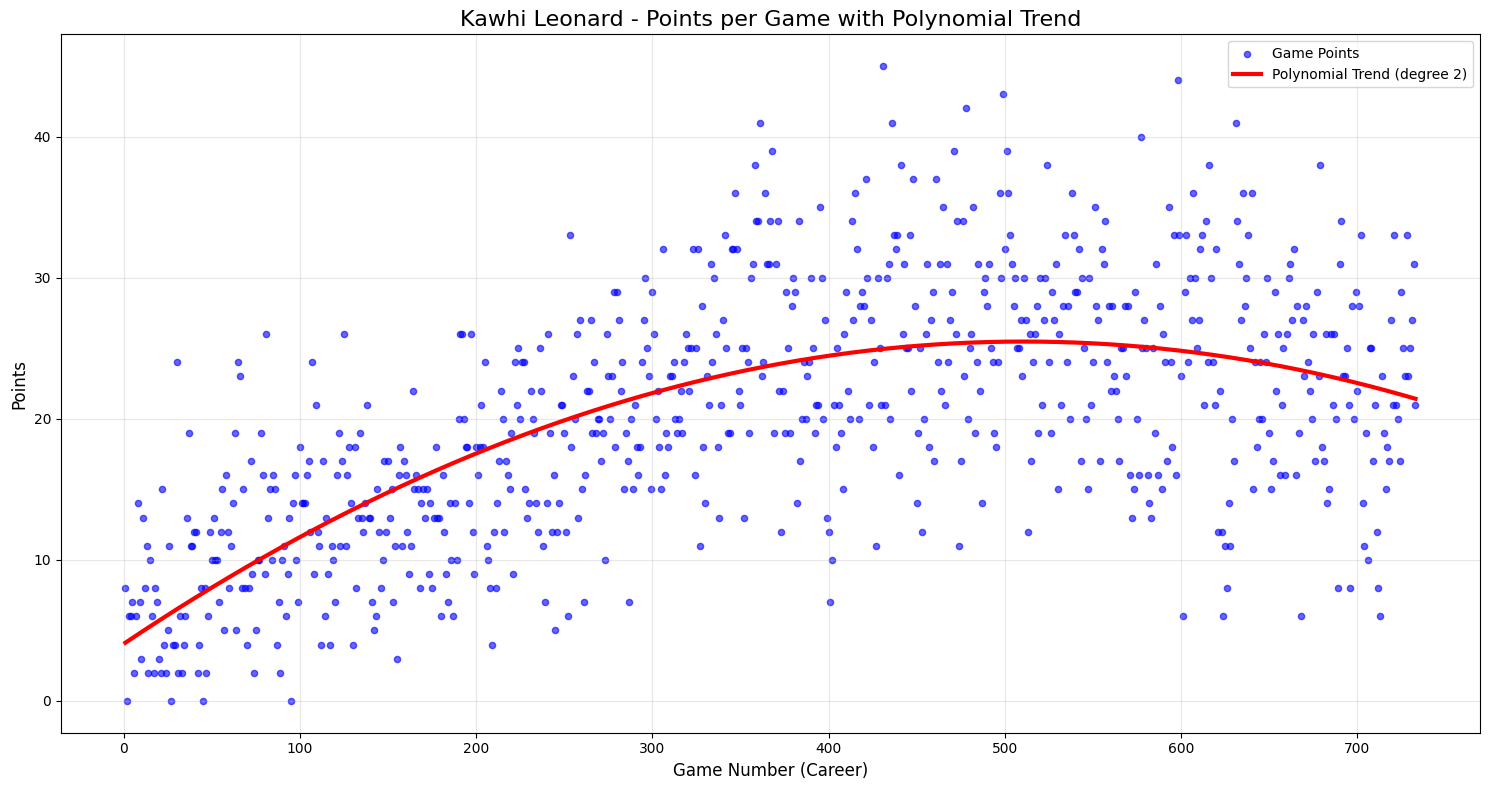

Polynomial regression R² score: 0.4534


In [14]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Create scatter plot with polynomial regression
plt.figure(figsize=(15, 8))

# Scatter plot of the original data
plt.scatter(all_games_df['GAME_NUMBER'], all_games_df['PTS'], alpha=0.6, s=20, color='blue', label='Game Points')

# Fit a 2nd degree polynomial regression
poly_reg = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_reg.fit(all_games_df['GAME_NUMBER'].values.reshape(-1, 1), all_games_df['PTS'])

# Generate smooth curve points
x_smooth = np.linspace(all_games_df['GAME_NUMBER'].min(), all_games_df['GAME_NUMBER'].max(), 300)
y_smooth = poly_reg.predict(x_smooth.reshape(-1, 1))

# Plot the polynomial curve
plt.plot(x_smooth, y_smooth, color='red', linewidth=3, label='Polynomial Trend (degree 2)')

plt.title("Kawhi Leonard - Points per Game with Polynomial Trend", fontsize=16)
plt.xlabel("Game Number (Career)", fontsize=12)
plt.ylabel("Points", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print R-squared score
r2_score = poly_reg.score(all_games_df['GAME_NUMBER'].values.reshape(-1, 1), all_games_df['PTS'])
print(f"Polynomial regression R² score: {r2_score:.4f}")